In [13]:
!pip install scanpy squidpy openpyxl --quiet


In [14]:
import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq

sc.settings.verbosity = 3
sc.set_figure_params(figsize=(6, 6))

In [16]:
counts = pd.read_csv("/content/pnas.1912459116.sd12.csv", index_col=0)
coordinates = pd.read_excel("/content/pnas.1912459116.sd15.xlsx", index_col=0)
print("Counts shape:", counts.shape)
print("Coordinates shape:", coordinates.shape)

counts.head()
coordinates.head()

Counts shape: (12903, 1368)
Coordinates shape: (645, 2)


,x_microns,y_microns
B1_cell1,-891.313702,-1464.550024
B1_cell2,-609.526668,-1457.751892
B1_cell3,-416.254156,-1451.438190
B1_cell4,-283.819862,-1470.768830
B1_cell5,-83.990122,-1472.083057


In [17]:
# If genes are rows, transpose
if counts.shape[0] < counts.shape[1]:
    print("Transposing counts...")
    counts = counts.T

print("New counts shape:", counts.shape)

New counts shape: (12903, 1368)


In [18]:
# Keep only numeric columns
coordinates = coordinates.select_dtypes(include=[np.number])

# Drop NaNs
coordinates = coordinates.dropna()

print("Cleaned coordinates:", coordinates.shape)

Cleaned coordinates: (645, 2)


In [19]:
common_cells = counts.index.intersection(coordinates.index)

counts = counts.loc[common_cells]
coordinates = coordinates.loc[common_cells]

print("After alignment:")
print(counts.shape, coordinates.shape)

After alignment:
(0, 1368) (0, 2)


In [20]:
adata_merfish = sc.AnnData(X=counts.values)

# Add gene + cell names
adata_merfish.obs_names = counts.index
adata_merfish.var_names = counts.columns

# Add spatial coordinates
adata_merfish.obsm["spatial"] = coordinates.iloc[:, :2].values

adata_merfish

AnnData object with n_obs × n_vars = 0 × 1368
    obsm: 'spatial'

In [21]:
sc.pp.calculate_qc_metrics(adata_merfish, inplace=True)

sc.pl.violin(adata_merfish, ['total_counts', 'n_genes_by_counts'], multi_panel=True)

ValueError: Cannot apply_along_axis when any iteration dimensions are 0

In [23]:
# Load data
counts = pd.read_csv(r"/content/pnas.1912459116.sd12.csv", index_col=0)
coordinates = pd.read_excel(r"/content/pnas.1912459116.sd15.xlsx", index_col=0)

print("Original shapes:")
print("Counts:", counts.shape)
print("Coordinates:", coordinates.shape)


# 🔥 STEP 1: Fix orientation
if counts.shape[0] < counts.shape[1]:
    counts = counts.T
    print("Transposed counts")

# 🔥 STEP 2: Clean coordinate index (IMPORTANT)
coordinates.index = coordinates.index.astype(str)
counts.index = counts.index.astype(str)

# 🔥 STEP 3: Try matching indices
common_cells = counts.index.intersection(coordinates.index)

print("Matching cells:", len(common_cells))

# ❗ IF NO MATCH → DO NOT FILTER
if len(common_cells) == 0:
    print("⚠️ No matching indices — forcing alignment by order")

    min_len = min(len(counts), len(coordinates))

    counts = counts.iloc[:min_len]
    coordinates = coordinates.iloc[:min_len]

else:
    counts = counts.loc[common_cells]
    coordinates = coordinates.loc[common_cells]


print("After alignment:")
print(counts.shape, coordinates.shape)

Original shapes:
Counts: (12903, 1368)
Coordinates: (645, 2)
Matching cells: 0
⚠️ No matching indices — forcing alignment by order
After alignment:
(645, 1368) (645, 2)


In [24]:
adata_merfish = sc.AnnData(X=counts.values)

adata_merfish.obs_names = counts.index
adata_merfish.var_names = counts.columns

# Take first 2 numeric columns as spatial
coordinates = coordinates.select_dtypes(include=[np.number])

adata_merfish.obsm["spatial"] = coordinates.iloc[:, :2].values

print(adata_merfish)

AnnData object with n_obs × n_vars = 645 × 1368
    obsm: 'spatial'


In [25]:
print("Final check:")
print("Cells:", adata_merfish.n_obs)
print("Genes:", adata_merfish.n_vars)

Final check:
Cells: 645
Genes: 1368


In [26]:
sc.pp.filter_cells(adata_merfish, min_counts=10)
sc.pp.filter_genes(adata_merfish, min_cells=3)

print(adata_merfish)

AnnData object with n_obs × n_vars = 645 × 1368
    obs: 'n_counts'
    var: 'n_cells'
    obsm: 'spatial'


In [27]:
sc.pp.normalize_total(adata_merfish, target_sum=1e4)
sc.pp.log1p(adata_merfish)

normalizing counts per cell
    finished (0:00:00)


extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


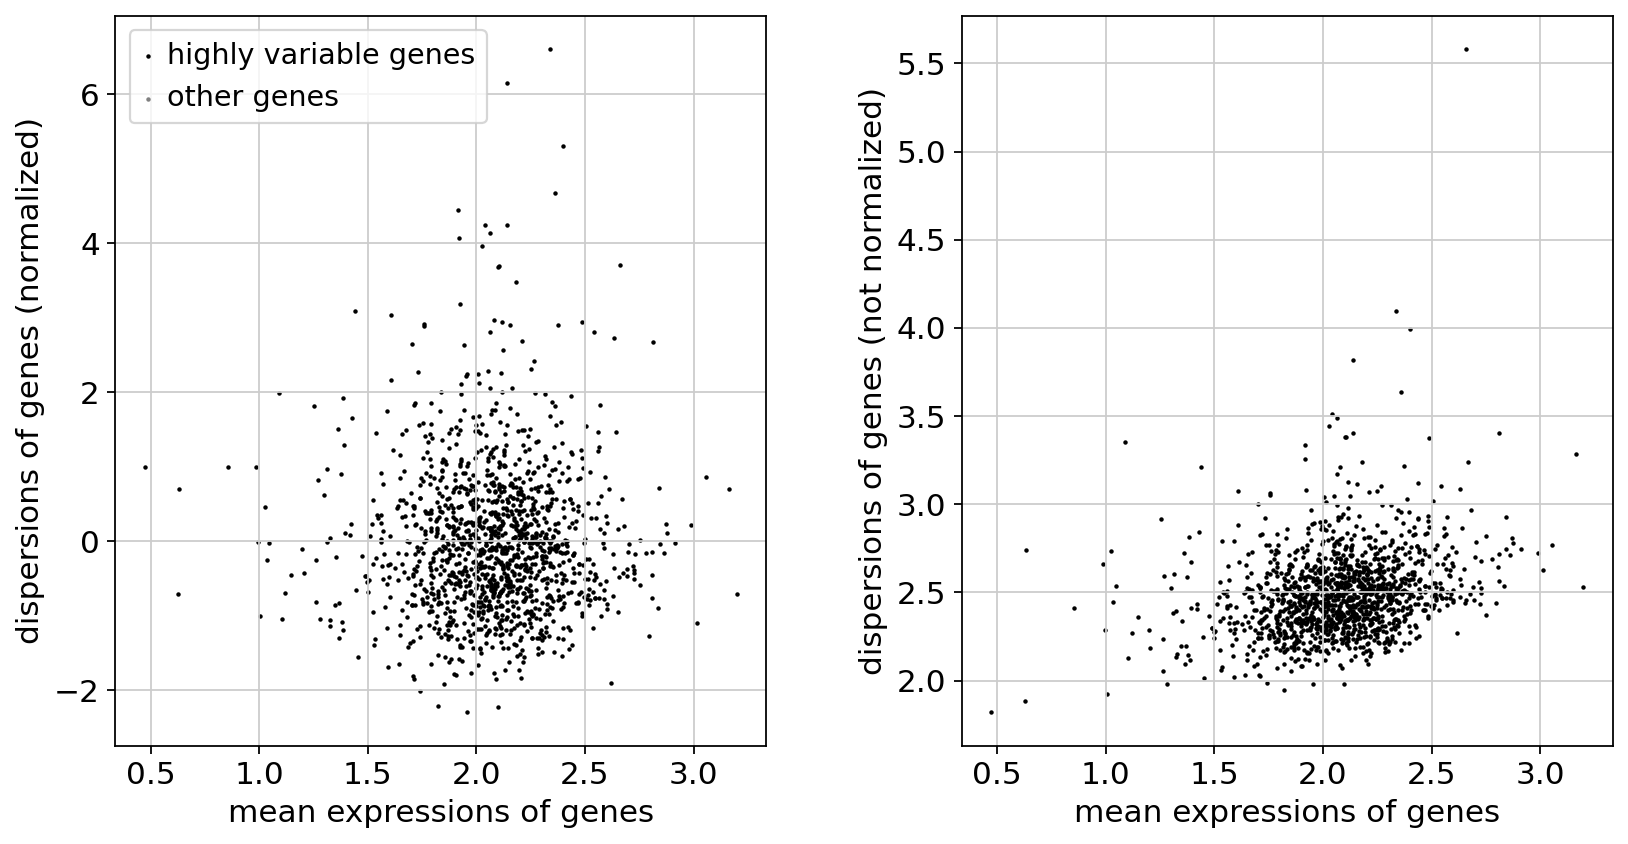

In [28]:
sc.pp.highly_variable_genes(adata_merfish, n_top_genes=2000, flavor="seurat")

sc.pl.highly_variable_genes(adata_merfish)

In [29]:
adata_merfish = adata_merfish[:, adata_merfish.var.highly_variable]

In [30]:
sc.pp.scale(adata_merfish, max_value=10)

/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:00)


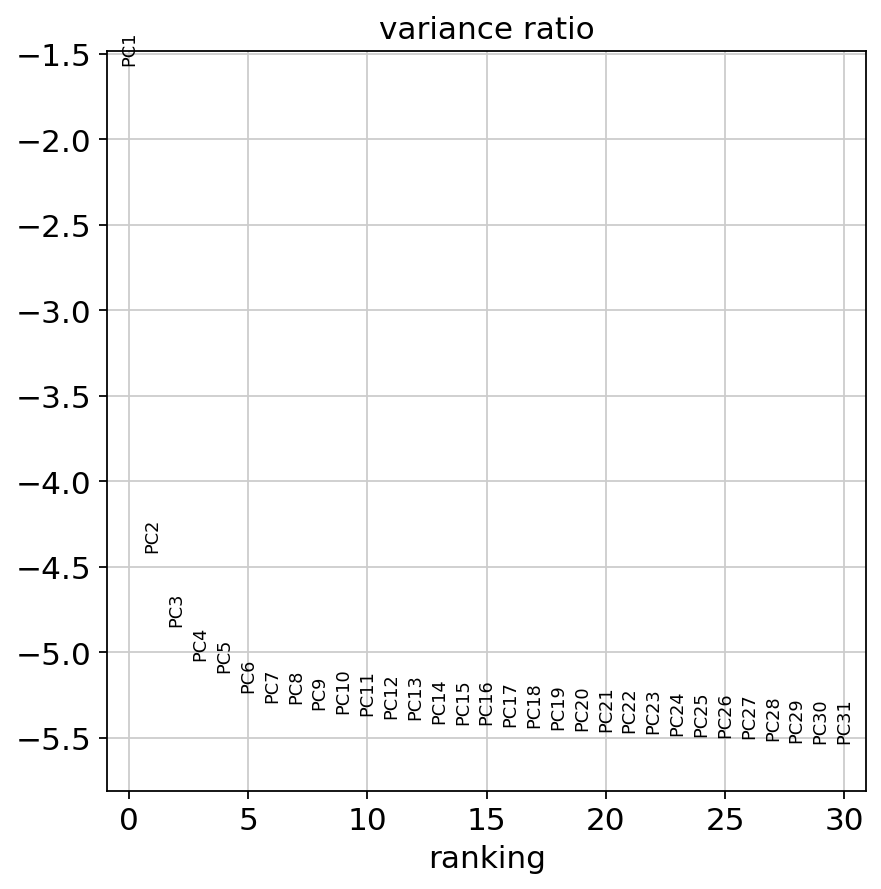

In [31]:
sc.tl.pca(adata_merfish)

sc.pl.pca_variance_ratio(adata_merfish, log=True)

In [32]:
sc.pp.neighbors(adata_merfish, n_neighbors=10, n_pcs=30)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:42)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


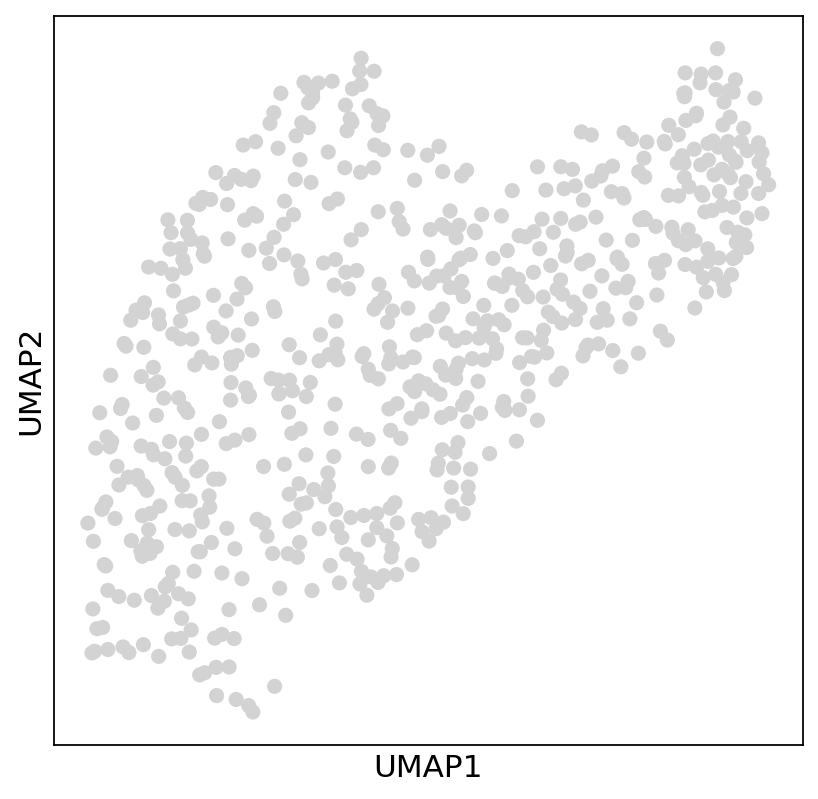

In [33]:
sc.tl.umap(adata_merfish)

sc.pl.umap(adata_merfish)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 91.9 MB/s eta 0:00:00
running Leiden clustering


/tmp/ipykernel_6233/3127719058.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_merfish, resolution=0.5)


    finished: found 5 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


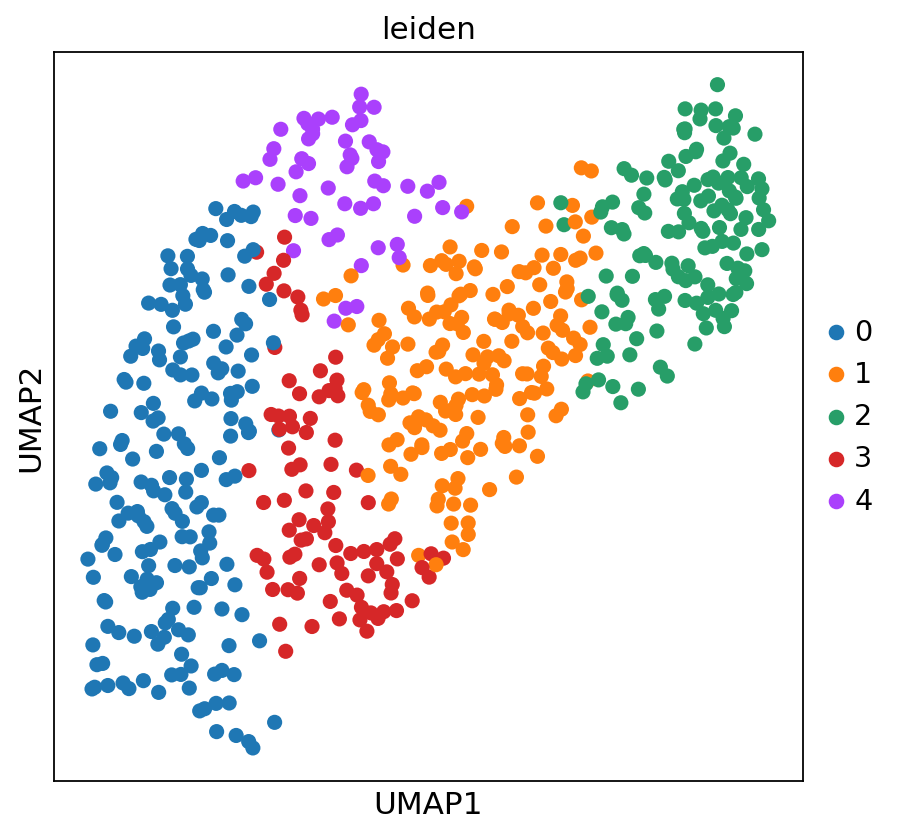

In [35]:
!pip install leidenalg --quiet
sc.tl.leiden(adata_merfish, resolution=0.5)

sc.pl.umap(adata_merfish, color="leiden")

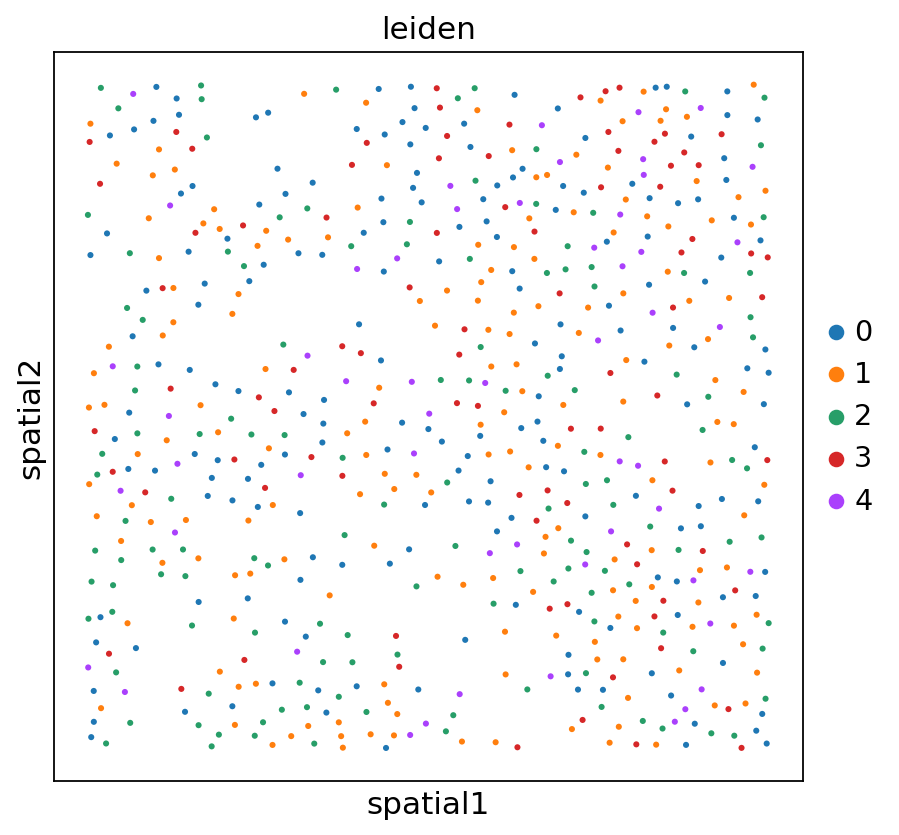

In [36]:
sc.pl.embedding(
    adata_merfish,
    basis="spatial",
    color="leiden",
    size=30
)

In [37]:
print(adata_merfish.var_names[:10])

Index(['B1_cell1', 'B1_cell2', 'B1_cell3', 'B1_cell4', 'B1_cell5', 'B1_cell6',
       'B1_cell7', 'B1_cell8', 'B1_cell9', 'B1_cell10'],
      dtype='object')


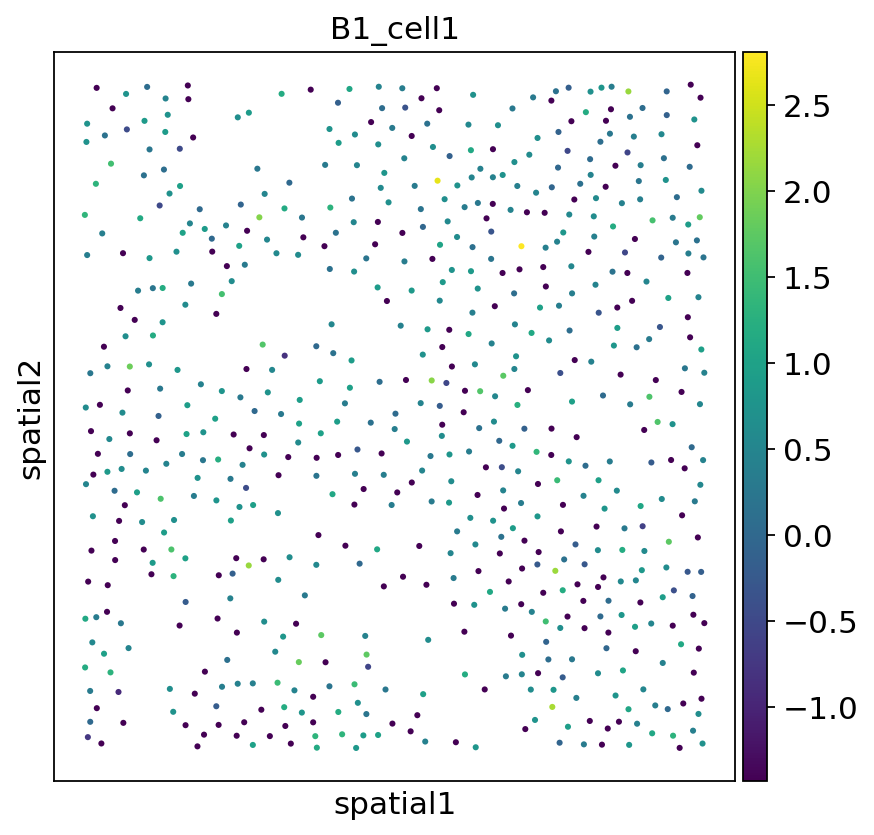

In [38]:
sc.pl.embedding(
    adata_merfish,
    basis="spatial",
    color=adata_merfish.var_names[0],  # change gene name if needed
    size=30
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


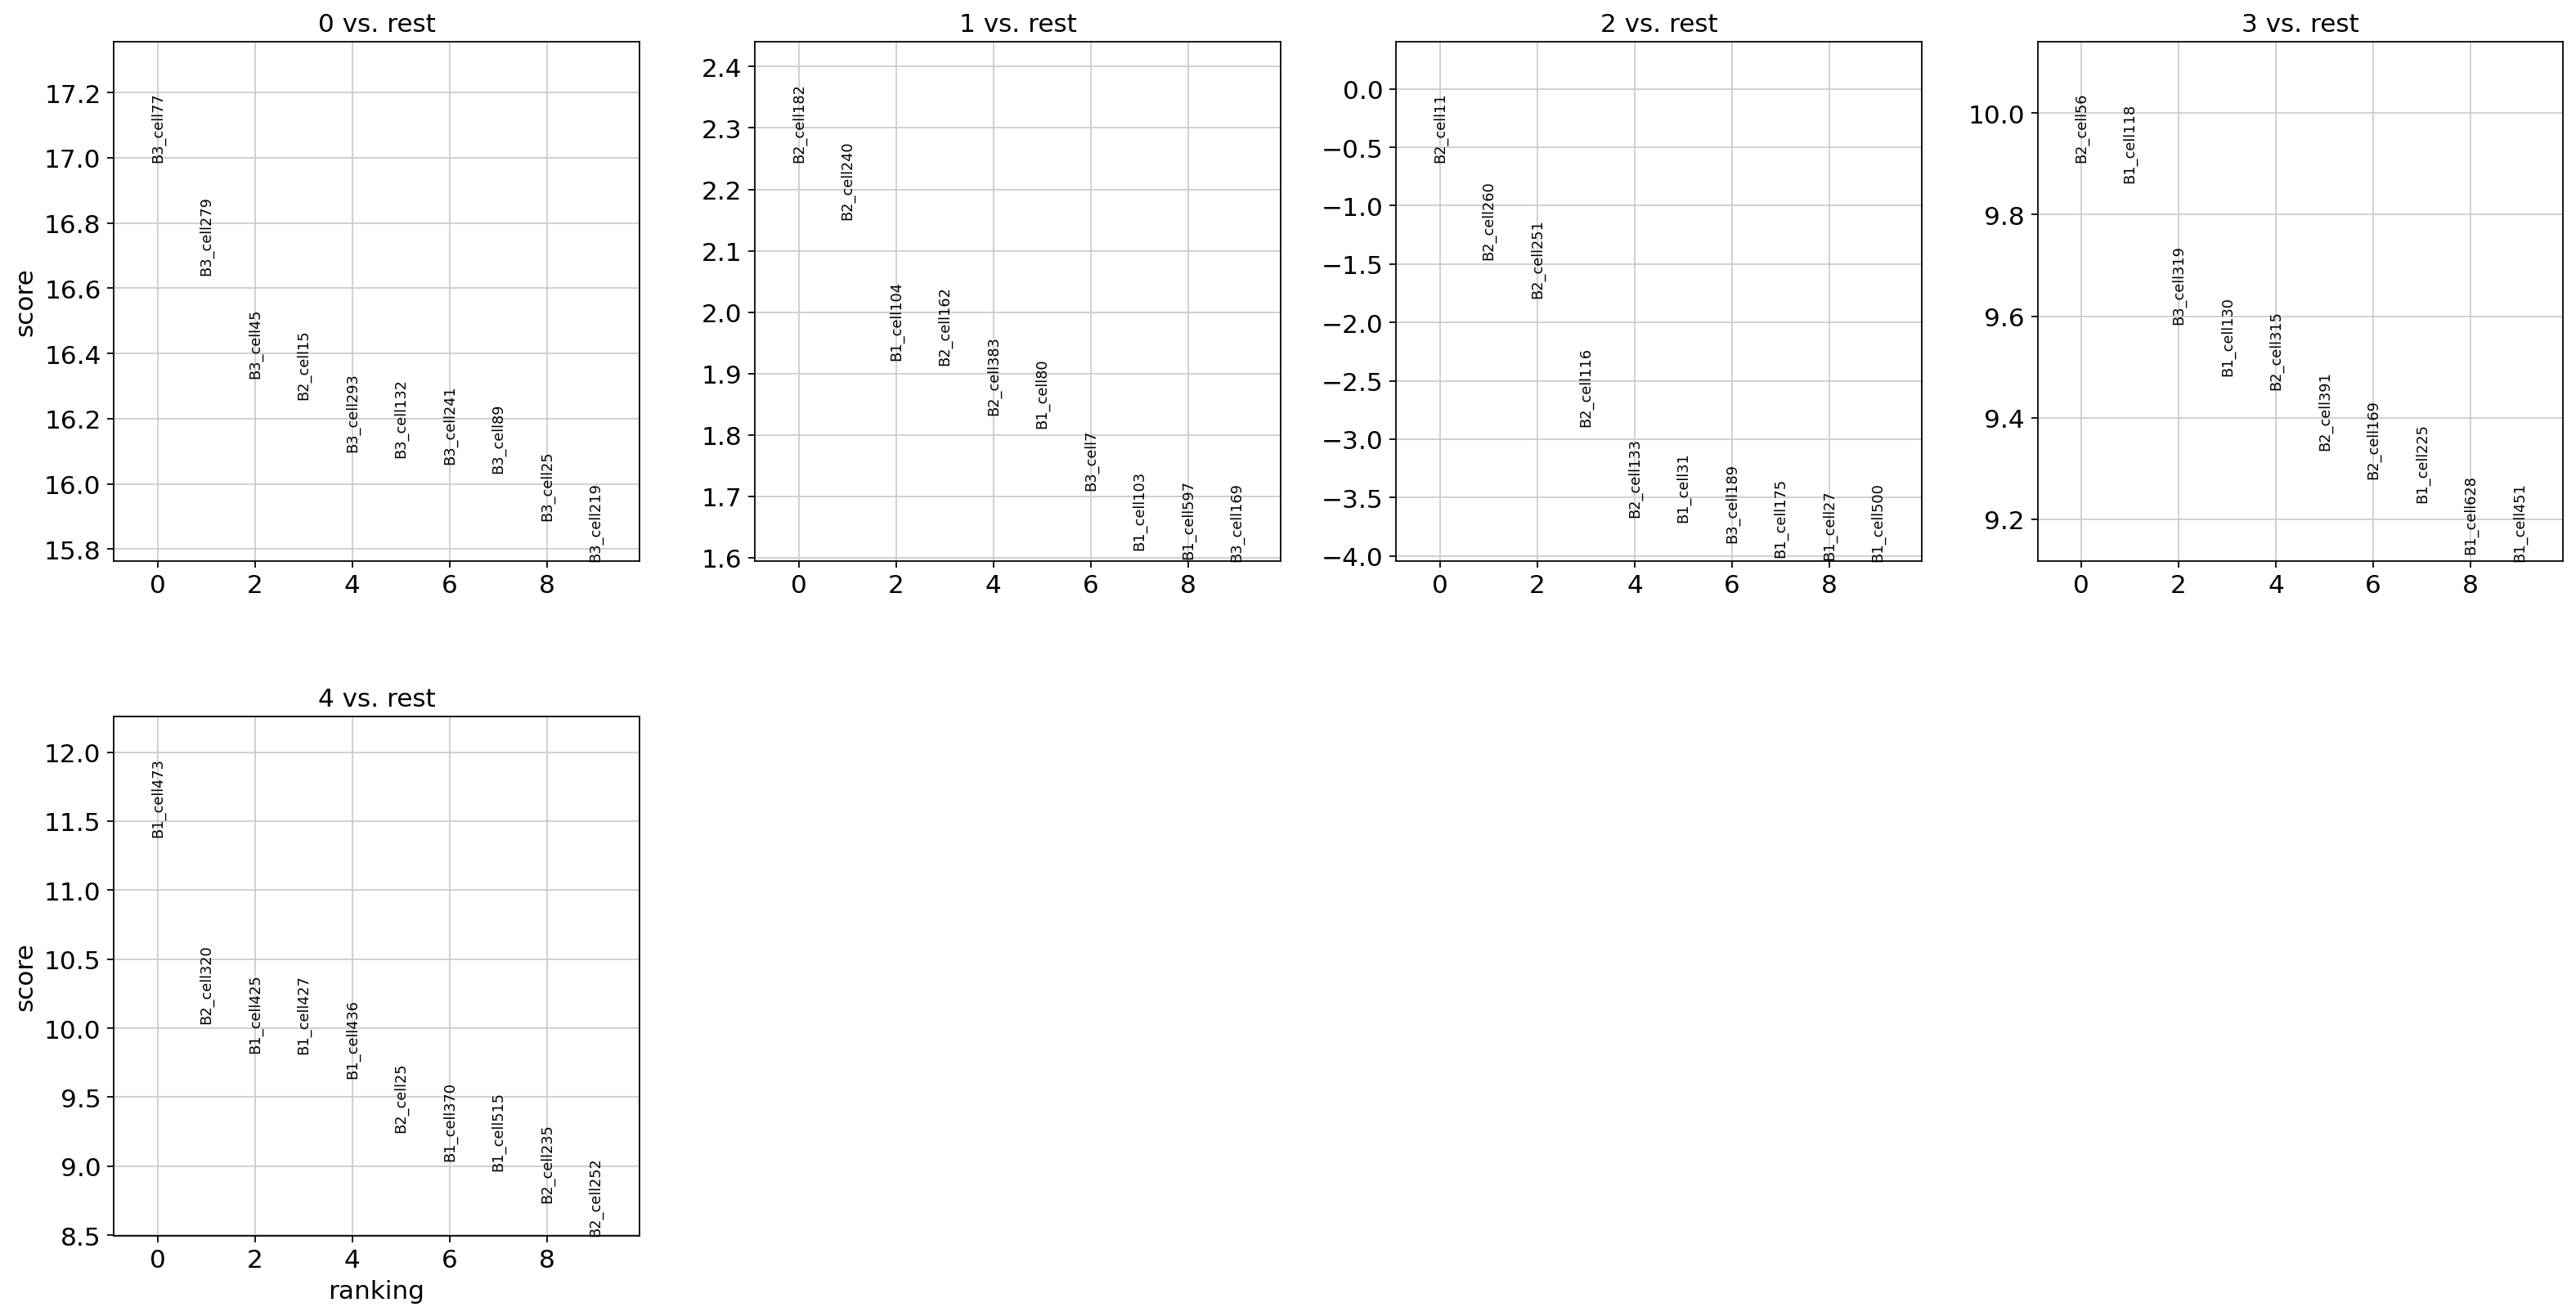

In [39]:
sc.tl.rank_genes_groups(adata_merfish, "leiden", method="t-test")

sc.pl.rank_genes_groups(adata_merfish, n_genes=10, sharey=False)

In [40]:
import squidpy as sq

sq.gr.spatial_neighbors(adata_merfish)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`


Calculating neighborhood enrichment using `1` core(s)


  0%|          | 0/1000 [00:00<?, ?/s]

Adding `adata.uns['leiden_nhood_enrichment']`
Finish (0:00:00)


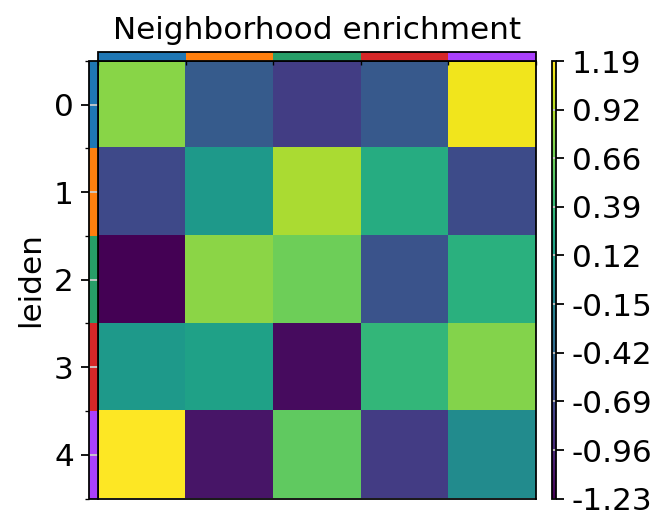

In [41]:
sq.gr.nhood_enrichment(adata_merfish, cluster_key="leiden")

sq.pl.nhood_enrichment(adata_merfish, cluster_key="leiden")

Calculating co-occurrence probabilities for `50` intervals using `None` core(s) and `None` splits
Adding `adata.uns['leiden_co_occurrence']`
Finish (0:00:00)


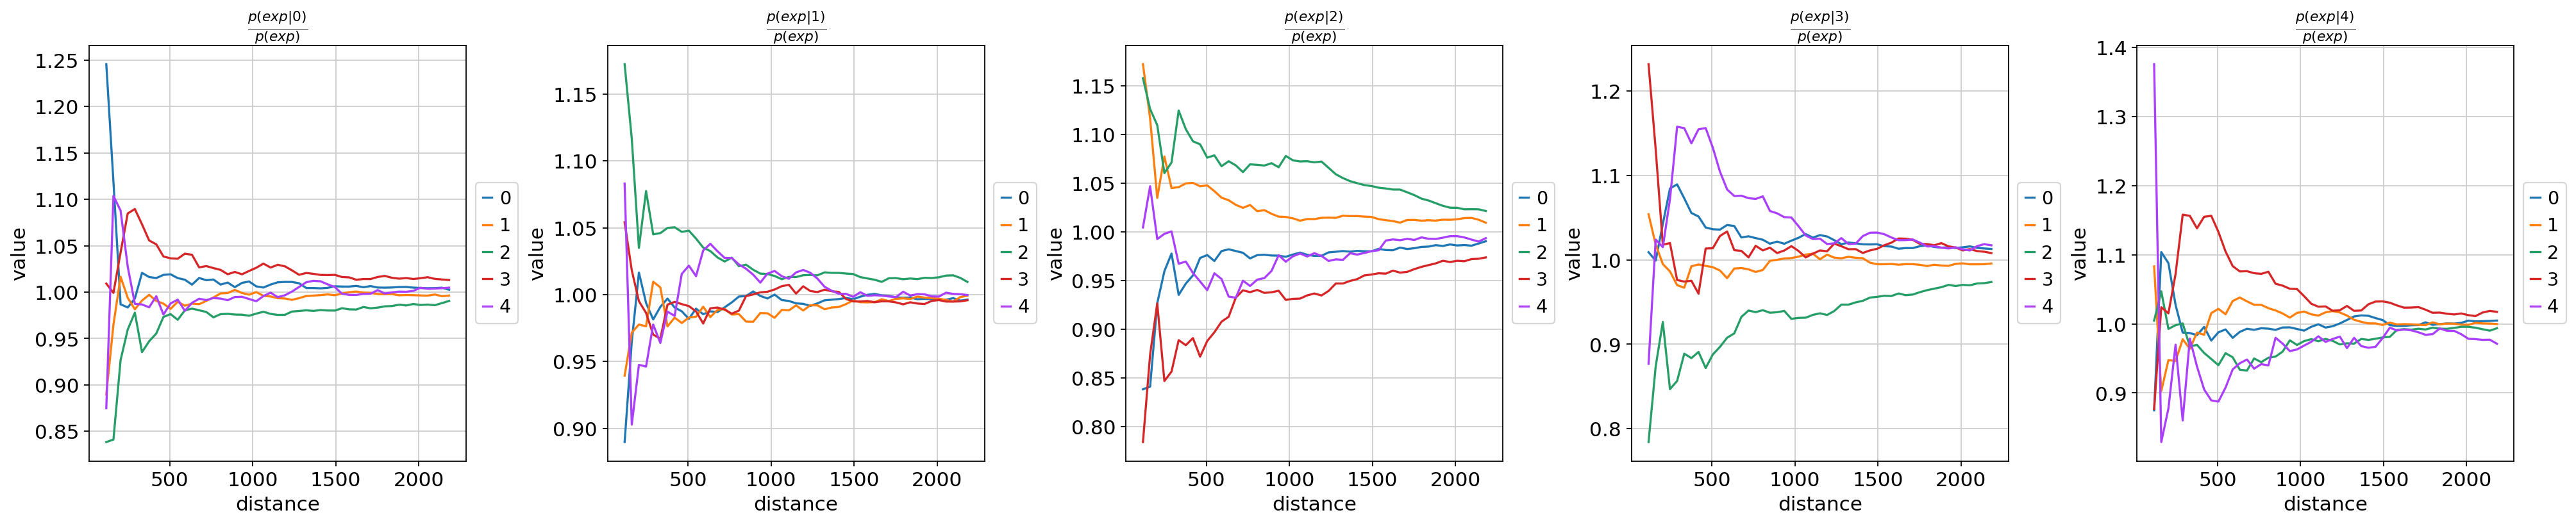

In [42]:
sq.gr.co_occurrence(adata_merfish, cluster_key="leiden")

sq.pl.co_occurrence(adata_merfish, cluster_key="leiden")

In [45]:
sq.gr.spatial_autocorr(adata_merfish, mode="moran")

# sq.pl.spatial_autocorr(adata_merfish, mode="moran") # This line caused an AttributeError

Calculating moran's statistic for `None` permutations using `1` core(s)
Adding `adata.uns['moranI']`
Finish (0:00:00)


AttributeError: module 'squidpy.pl' has no attribute 'spatial_autocorr'

In [46]:
moran_df = adata_merfish.uns["moranI"]

# Sort genes by spatial signal
moran_df = moran_df.sort_values("I", ascending=False)

moran_df.head(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
B1_cell549,0.083142,0.000053,0.000477,0.071888
B3_cell265,0.076153,0.000187,0.000477,0.115840
B2_cell267,0.073413,0.000299,0.000477,0.115840
B1_cell550,0.072247,0.000363,0.000477,0.115840
B2_cell131,0.067979,0.000726,0.000477,0.115840
B3_cell106,0.067677,0.000761,0.000477,0.115840
B3_cell128,0.066754,0.000880,0.000477,0.115840
B2_cell266,0.066591,0.000903,0.000477,0.115840
B3_cell186,0.066354,0.000936,0.000477,0.115840
B3_cell313,0.066005,0.000988,0.000477,0.115840


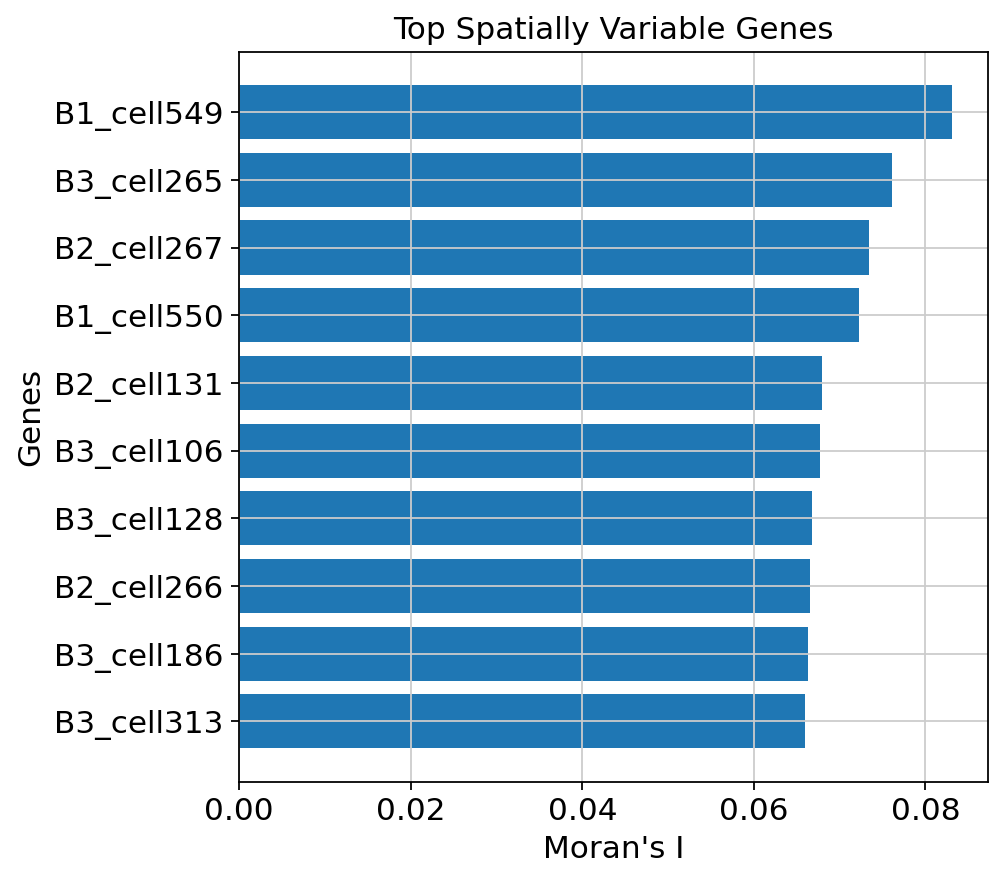

In [47]:
import matplotlib.pyplot as plt

top_genes = moran_df.head(10)

plt.figure()
plt.barh(top_genes.index, top_genes["I"])
plt.xlabel("Moran's I")
plt.ylabel("Genes")
plt.title("Top Spatially Variable Genes")
plt.gca().invert_yaxis()
plt.show()

In [48]:
moran_df.to_csv("moran_results.csv")